In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import sent_tokenize

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
from transformers import logging

logging.set_verbosity_error()


def setup_nltk():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt", quiet=True)

setup_nltk()

#### Load the dataset

In [3]:
DOCS_DIR = Path(r"../ebm_nlp_2_00/documents")

# Read only .txt files
text_files = sorted(DOCS_DIR.glob("*.txt"))

print(f"Number of .text files found: {len(text_files)}")
print("First 5 files:")
for f in text_files[:5]:
    print(f.name)

Number of .text files found: 4993
First 5 files:
10036953.txt
10037531.txt
10052279.txt
10070173.txt
10071998.txt


#### Empty sentences were removed to avoid introducing noise and invalid inputs into the embedding and clustering process

In [5]:
def split_into_sentences_raw(text: str):
    sentences = sent_tokenize(text)
    sentences = [s for s in sentences if s.strip() != ""]
    return sentences

#### Sentence Extraction

In [7]:

import nltk

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)


rows = []

for file_path in text_files:
    pmid = file_path.stem
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    
    
    sentences = split_into_sentences_raw(text)
    
    for sent_id, sent in enumerate(sentences):
        rows.append({
            "pmid": pmid,
            "sentence_id": sent_id,
            "sentence": sent
        })

df_work = pd.DataFrame(rows)

print(f"Total number of sentences: {len(df_work)}")
print(df_work)

Total number of sentences: 53544
           pmid  sentence_id  \
0      10036953            0   
1      10036953            1   
2      10036953            2   
3      10036953            3   
4      10036953            4   
...         ...          ...   
53539   9989713           10   
53540   9989713           11   
53541   9989713           12   
53542   9989713           13   
53543   9989713           14   

                                                sentence  
0      [Triple therapy regimens involving H2 blockade...  
1      Comparison of ranitidine and lansoprazole in s...  
2      To evaluate the efficacy and safety of two 1-w...  
3      The drug combination and administration period...  
4      The ranitidine group received RNT 300 mg, CAM ...  
...                                                  ...  
53539  FINDINGS 23 patients in the AT group and four ...  
53540  The subjective global assessments of the effec...  
53541  A per-protocol analysis did not show appreci

### Sentence Embedding

Sentences were encoded into dense vector representations using a pre-trained transformer model.  
These embeddings are used for downstream clustering.

In [9]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)

sentences = df_work["sentence"].tolist()
embeddings = embedder.encode(
    sentences,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/837 [00:00<?, ?it/s]

embeddings shape: (53544, 384)


 K-means Clustering

In [11]:
n_cluster_dict = {}

for n in range(3, 9):
    kmeans = KMeans(
        n_clusters=n,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(embeddings)
    n_cluster_dict[n] = cluster_labels

    print(pd.Series(cluster_labels).value_counts().sort_index())

D:\envs\text_analytics\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


0    13462
1    19967
2    20115
Name: count, dtype: int64
0    14668
1    12844
2    13745
3    12287
Name: count, dtype: int64
0     9205
1    12525
2    13266
3    12617
4     5931
Name: count, dtype: int64
0     8936
1    12604
2    10862
3    12674
4     2538
5     5930
Name: count, dtype: int64
0     9961
1     9879
2     2477
3    11892
4     5805
5     5184
6     8346
Name: count, dtype: int64
0    7437
1    9479
2    3500
3    8660
4    6130
5    2309
6    7611
7    8418
Name: count, dtype: int64


 Hierarchical clustering (HAC) 
Cluster sizes were examined to assess the distribution.

In [13]:
# hac = AgglomerativeClustering(
#     n_clusters=3,
#     metric='cosine',
#     linkage='average'
# )

# sample_size = 5000
# sample_idx = np.random.RandomState(42).choice(len(embeddings), size=sample_size, replace=False)
# embeddings_sample = embeddings[sample_idx]

# cluster_labels_sample = hac.fit_predict(embeddings_sample)

# cluster_labels = -1 * np.ones(len(df_work), dtype=int)
# cluster_labels[sample_idx] = cluster_labels_sample
# df_work["cluster_hac"] = cluster_labels

# print(df_work["cluster_hac"].value_counts().sort_index())


hac = AgglomerativeClustering(
    n_clusters=3,
    metric="cosine",
    linkage="average"
)

cluster_labels = hac.fit_predict(embeddings)

df_work["cluster_hac"] = cluster_labels

print(df_work["cluster_hac"].value_counts().sort_index())

cluster_hac
0    53152
1        3
2      389
Name: count, dtype: int64


 Clustering Evaluation and Results

In [15]:
df_work["cluster"] = n_cluster_dict[4]
score_kmeans = silhouette_score(embeddings, df_work["cluster"])
print("KMeans:", score_kmeans)


score_hac = silhouette_score(embeddings, df_work["cluster_hac"])
print("HAC:", score_hac)
# 14:06 minutes to run

KMeans: 0.023573869839310646
HAC: 0.04929596930742264


In [16]:
for n, cluster_labels in n_cluster_dict.items():
    score_kmeans = silhouette_score(embeddings, cluster_labels)
    print(f"KMeans silhouette score when n={n}: {score_kmeans}")

KMeans silhouette score when n=3: 0.025092341005802155
KMeans silhouette score when n=4: 0.023573869839310646
KMeans silhouette score when n=5: 0.02346687950193882
KMeans silhouette score when n=6: 0.02372179552912712
KMeans silhouette score when n=7: 0.024485355243086815
KMeans silhouette score when n=8: 0.023981189355254173


### Visualization

In [18]:
def plot_clusters_pca(embeddings, labels, title="Cluster visualization (PCA)"):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(embeddings)

    df_plot = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "cluster": labels.astype(str)
    })

    plt.figure(figsize=(10, 8))

    for c in sorted(df_plot["cluster"].unique()):
        sub = df_plot[df_plot["cluster"] == c]
        plt.scatter(sub["x"], sub["y"], alpha=0.6, s=18, label=f"Cluster {c}")

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

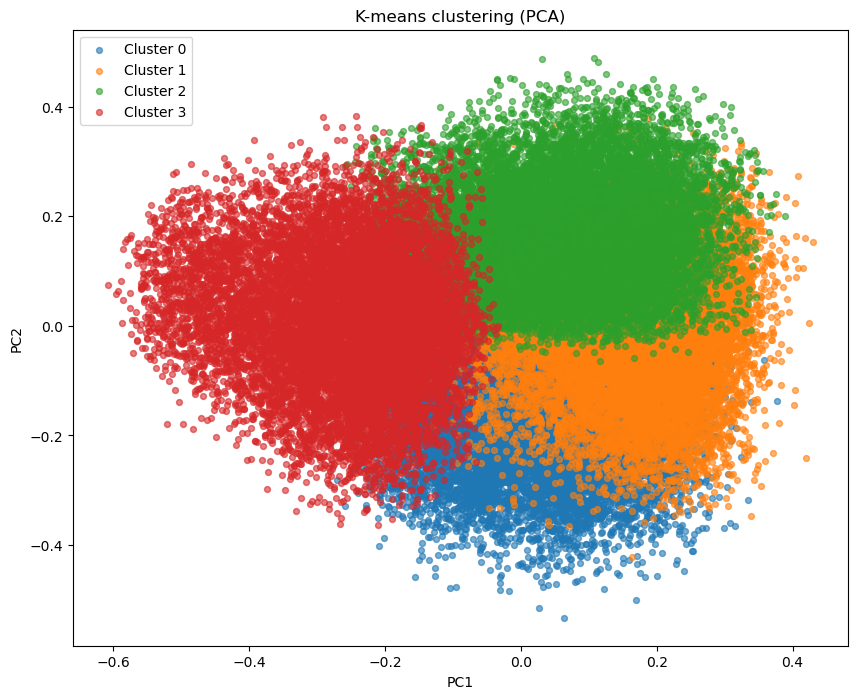

In [19]:
plot_clusters_pca(
    embeddings,
    df_work["cluster"],
    title="K-means clustering (PCA)"
)

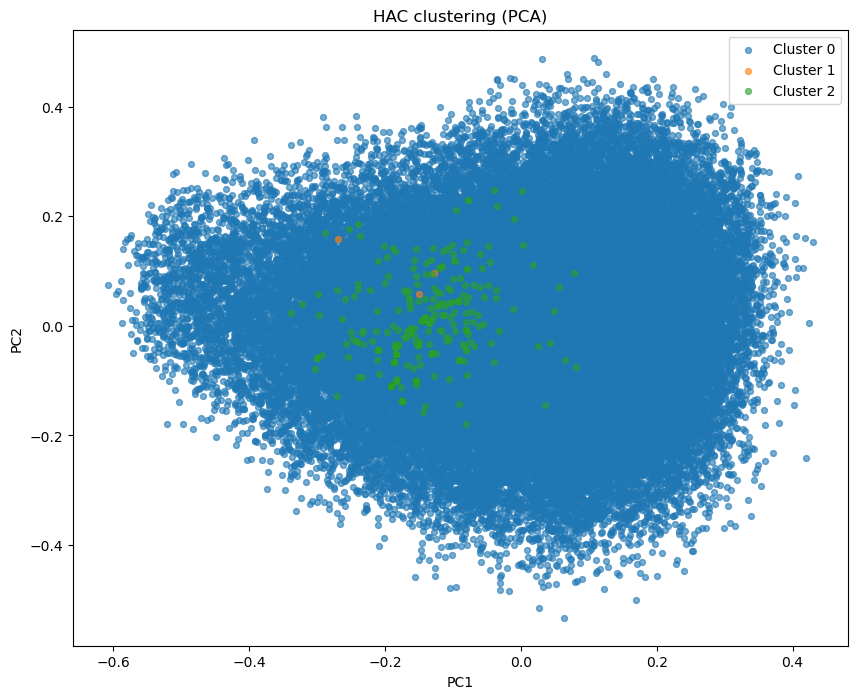

In [20]:
plot_clusters_pca(
    embeddings,
    df_work["cluster_hac"],
    title="HAC clustering (PCA)"
)

In [21]:
def inspect_cluster_content(
    df,
    label_col,
    text_col="sentence",
    n_examples=8,
    random_state=42
):
    print(f"\n{'='*80}")
    print(f"Inspecting clusters for: {label_col}")
    print(f"{'='*80}")

    for cid in sorted(df[label_col].unique()):
        sub = df[df[label_col] == cid].copy()
        print(f"\n--- Cluster {cid} | size = {len(sub)} ---")

        vec = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            max_features=3000
        )
        X = vec.fit_transform(sub[text_col])
        scores = np.asarray(X.mean(axis=0)).ravel()
        terms = vec.get_feature_names_out()
        top_idx = scores.argsort()[::-1][:10]
        top_terms = [terms[i] for i in top_idx]

        print("Top terms:", ", ".join(top_terms))

        # Show example sentences
        examples = (
            sub[text_col]
            .drop_duplicates()
            .sample(n=min(n_examples, sub[text_col].nunique()), random_state=random_state)
            .tolist()
        )

        print("Example sentences:")
        for i, sent in enumerate(examples, 1):
            print(f"{i}. {sent}")

Results and Analysis of K-Means

Inspection of the K-means clusters indicated that the sentence groups did not align clearly with the target schema fields. Instead of separating population, intervention, and outcome information into distinct clusters, the results showed substantial mixing across fields. For instance, Cluster 0 contained a population sentence (“152 children were recruited”), an outcome sentence (“The primary outcome measure was significant improvement...”), and an intervention sentence (“The training intervention consisted of 6 supervised training sessions...” ). Cluster 1 showed a weak treatment-related tendency, with terms such as mg, placebo, dose, and treatment, but it still mixed intervention-related content with patient descriptions and background information. Cluster 3 was more strongly associated with result and comparison language, including terms such as significant, vs, and differences, yet it also contained other trial-related content rather than a pure outcome field. These findings suggest that K-means captures only weak thematic structure in the sentence embeddings and does not provide clusters that correspond cleanly to the predefined schema fields. As a result, clustering is more useful as an exploratory step than as a reliable extraction strategy.

In [23]:
# Inspect K-means clusters
inspect_cluster_content(df_work, label_col="cluster")


Inspecting clusters for: cluster

--- Cluster 0 | size = 14668 ---
Top terms: patients, group, treatment, study, trial, results, randomized, months, cancer, clinical
Example sentences:
1. From December 1986 to August 1989, patients with small choroidal melanoma, not large enough to be eligible for the COMS clinical trials, were offered participation in a nonrandomized prospective follow-up study.
2. Mean terminal half-life was approximately 6 weeks.
3. [Local therapy of grade 1 and 2 hemorrhoids.
4. Esophageal cancer (EC) is also a common cause of death due to cancer among males.
5. The findings could influence urological and primary care practice by including questions on ED during routine consultations and relevant clinical protocols.
6. The two groups were compared for operative and hospitalization times and postoperative course.
7. In the EBUS-TBNA plus CDPs group (99 patients), TBNA, TBB, and BW were performed.
8. CONCLUSIONS Mitral surgery produces an atrial postoperative volume

### Results and Analysis of HAC
Inspection of the HAC clusters showed that the resulting groups did not align with the target schema fields. Unlike K-means, HAC produced one overwhelmingly large cluster and several extremely small clusters, indicating poor separation in the embedding space. The large cluster mixed population, treatment, and outcome information, while the small clusters appeared to capture only isolated or unusual sentences rather than meaningful schema categories. For example, Cluster 1 included sentences about participant allocation, treatment comparability, and observed improvement, whereas Cluster 3 contained only a single sentence. Overall, HAC did not recover useful natural groupings for the predefined schema fields and was less informative than K-means in this preliminary analysis.

In [25]:
# Inspect HAC clusters
inspect_cluster_content(df_work, label_col="cluster_hac")


Inspecting clusters for: cluster_hac

--- Cluster 0 | size = 53152 ---
Top terms: patients, group, treatment, study, results, groups, trial, randomized, placebo, significant
Example sentences:
1. PaO2 in the CPAP group showed a significant increase by the end of the initial study; whereas intrapulmonary shunt and alveolar-arterial oxygen tension gradient AaDO2 revealed simultaneously a significant reduction.
2. CONCLUSION Ten percent HES 130/0.4 was equally effective and safe as compared to 10% HES 200/0.5 for volume therapy in patients undergoing cardiovascular surgery.
3. PURPOSE To determine the effectiveness of the Alleviating Depression Among Patients With Cancer (ADAPt-C) collaborative care management for major depression or dysthymia.
4. Fasting blood samples were taken before treatment, and after cycles 3 and 6, between the 18th and the 22nd day of the cycle.
5. Analysis, blinded to position, was made using nonparametric statistics.
6. PATIENTS Sixteen consecutive patients wit